# Model Benchmarking

Train LSTM, DeepAR, and TFT on `data_original` and `data_1to7`, then compare against Chronos-2. The summary at the end reports RMSE on train/val/test for each dataset.


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts.training_script import train_model

MODEL_TYPES = ["lstm", "deepar", "tft"]
DATASETS = ["data_original", "data_1to7"]
SPLITS = ["train", "val", "test"]

CONTEXT_LENGTH = 12
FORECAST_LENGTH = 1
QUANTILES = (0.1, 0.5, 0.9)
MAX_EPOCHS = 100
PATIENCE = 3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_HEADS = 4

RESULTS_DIR = Path("results/benchmarks")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _extract_last_rmse(history):
    return {split: history[f"{split}_rmse"][-1] for split in SPLITS}

def train_all():
    train_results = {}
    train_histories = {}
    for dataset in DATASETS:
        for model in MODEL_TYPES:
            print(f"Training {model} on {dataset}...")
            history = train_model(
                model_type=model,
                dataset_base=dataset,
                context_length=CONTEXT_LENGTH,
                forecast_length=FORECAST_LENGTH,
                quantiles=QUANTILES,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                hidden_size=HIDDEN_SIZE,
                num_layers=NUM_LAYERS,
                num_heads=NUM_HEADS,
            )
            train_histories[(dataset, model)] = history
            train_results[(dataset, model)] = _extract_last_rmse(history)
    return train_results, train_histories

def eval_chronos2(dataset, split):
    data_path = Path("data/datasets") / f"{dataset}_{split}.csv"
    out_path = RESULTS_DIR / f"chronos2_{dataset}_{split}.json"
    cmd = [
        sys.executable,
        "scripts/chronos2_eval.py",
        "--data-path",
        str(data_path),
        "--context-length",
        str(CONTEXT_LENGTH),
        "--forecast-length",
        str(FORECAST_LENGTH),
        "--quantiles",
        ",".join(str(q) for q in QUANTILES),
        "--output-path",
        str(out_path),
    ]
    subprocess.run(cmd, check=True)
    return json.loads(out_path.read_text())


## Train baseline models

This runs LSTM, DeepAR, and TFT on both datasets. RMSE shown is the final epoch value returned by the trainer.


In [2]:
train_results, train_histories = train_all()

train_rows = []
for (dataset, model), metrics in train_results.items():
    for split, rmse in metrics.items():
        train_rows.append(
            {"dataset": dataset, "split": split, "model": model, "rmse": rmse}
        )

train_df = pd.DataFrame(train_rows)
train_pivot = train_df.pivot_table(
    index=["dataset", "split"], columns="model", values="rmse"
).sort_index()
train_pivot


Training lstm on data_original...
Epoch 1/100 - train_loss=4.793 - train_rmse=16.201 - val_loss=6.017 - val_rmse=21.465 - test_loss=5.575 - test_rmse=19.970 
Epoch 2/100 - train_loss=2.197 - train_rmse=10.693 - val_loss=3.635 - val_rmse=15.273 - test_loss=3.261 - test_rmse=13.899 
Epoch 3/100 - train_loss=1.417 - train_rmse=7.885 - val_loss=2.684 - val_rmse=12.875 - test_loss=2.544 - test_rmse=11.546 
Epoch 4/100 - train_loss=1.161 - train_rmse=6.778 - val_loss=2.130 - val_rmse=11.471 - test_loss=2.018 - test_rmse=10.078 
Epoch 5/100 - train_loss=1.021 - train_rmse=6.065 - val_loss=1.847 - val_rmse=10.489 - test_loss=1.716 - test_rmse=8.977 
Epoch 6/100 - train_loss=0.937 - train_rmse=5.574 - val_loss=1.602 - val_rmse=9.749 - test_loss=1.456 - test_rmse=8.189 
Epoch 7/100 - train_loss=0.896 - train_rmse=5.300 - val_loss=1.502 - val_rmse=9.318 - test_loss=1.379 - test_rmse=7.736 
Epoch 8/100 - train_loss=0.862 - train_rmse=5.096 - val_loss=1.401 - val_rmse=8.981 - test_loss=1.286 - test

'Final metrics'

,metric,value
0,train_loss,0.750
1,train_rmse,4.205
2,val_loss,1.130
3,val_rmse,7.338
4,train_q0.1,0.493
5,train_q0.5,1.105
6,train_q0.9,0.652
7,val_q0.1,0.807
8,val_q0.5,1.702
9,val_q0.9,1.109


Training deepar on data_original...
Epoch 1/100 - train_loss=2.635 - train_rmse=6.437 - val_loss=2.938 - val_rmse=5.401 - test_loss=2.711 - test_rmse=4.403 
Epoch 2/100 - train_loss=2.435 - train_rmse=4.244 - val_loss=2.852 - val_rmse=4.962 - test_loss=2.697 - test_rmse=4.714 
Epoch 3/100 - train_loss=2.345 - train_rmse=3.875 - val_loss=2.618 - val_rmse=3.705 - test_loss=2.391 - test_rmse=3.317 
Epoch 4/100 - train_loss=2.331 - train_rmse=3.815 - val_loss=2.623 - val_rmse=3.941 - test_loss=2.398 - test_rmse=3.434 
Epoch 5/100 - train_loss=2.307 - train_rmse=3.801 - val_loss=2.583 - val_rmse=3.535 - test_loss=2.357 - test_rmse=3.226 
Epoch 6/100 - train_loss=2.300 - train_rmse=3.824 - val_loss=2.631 - val_rmse=3.677 - test_loss=2.421 - test_rmse=3.503 
Epoch 7/100 - train_loss=2.296 - train_rmse=3.775 - val_loss=2.590 - val_rmse=3.466 - test_loss=2.372 - test_rmse=3.418 
Early stopping at epoch 8: train_rmse=3.774, val_rmse=3.823, test_rmse=3.798


'Final metrics'

...

,metric,value
0,train_loss,1.665
1,train_rmse,2.452
2,val_loss,2.192
3,val_rmse,3.943
4,train_q0.1,0.254
5,train_q0.5,0.807
6,train_q0.9,0.306
7,val_q0.1,0.431
8,val_q0.5,1.342
9,val_q0.9,0.515


Training tft on data_1to7...
Epoch 1/100 - train_loss=0.423 - train_rmse=3.053 - val_loss=0.658 - val_rmse=4.646 - test_loss=0.696 - test_rmse=4.975 
Epoch 2/100 - train_loss=0.384 - train_rmse=2.904 - val_loss=0.682 - val_rmse=4.550 - test_loss=0.714 - test_rmse=4.888 
Epoch 3/100 - train_loss=0.376 - train_rmse=2.849 - val_loss=0.619 - val_rmse=4.345 - test_loss=0.646 - test_rmse=4.588 
Epoch 4/100 - train_loss=0.373 - train_rmse=2.852 - val_loss=0.629 - val_rmse=4.407 - test_loss=0.656 - test_rmse=4.629 
Epoch 5/100 - train_loss=0.370 - train_rmse=2.820 - val_loss=0.618 - val_rmse=4.492 - test_loss=0.641 - test_rmse=4.683 
Epoch 6/100 - train_loss=0.370 - train_rmse=2.847 - val_loss=0.620 - val_rmse=4.468 - test_loss=0.645 - test_rmse=4.696 
Epoch 7/100 - train_loss=0.369 - train_rmse=2.860 - val_loss=0.614 - val_rmse=4.498 - test_loss=0.640 - test_rmse=4.711 
Epoch 8/100 - train_loss=0.367 - train_rmse=2.859 - val_loss=0.623 - val_rmse=4.587 - test_loss=0.650 - test_rmse=4.820 
Epo

'Final metrics'

,metric,value
0,train_loss,0.368
1,train_rmse,2.877
2,val_loss,0.616
3,val_rmse,4.446
4,train_q0.1,0.171
5,train_q0.5,0.664
6,train_q0.9,0.269
7,val_q0.1,0.291
8,val_q0.5,1.130
9,val_q0.9,0.431


model                  deepar      lstm       tft
dataset       split                              
data_1to7     test   4.087921  4.680767  4.650366
              train  2.451830  2.834028  2.876751
              val    3.943124  4.501174  4.445585
data_original test   3.798176  5.423223  3.431744
              train  3.774308  4.204896  3.817992
              val    3.822844  7.338350  5.844473

## Chronos-2 evaluation

Chronos-2 is evaluated on each split for both datasets using the same context length and quantiles.


In [3]:
chronos_rows = []
for dataset in DATASETS:
    for split in SPLITS:
        print(f"Evaluating Chronos-2 on {dataset} {split}...")
        result = eval_chronos2(dataset, split)
        chronos_rows.append(
            {
                "dataset": dataset,
                "split": split,
                "model": "chronos2",
                "rmse": result["rmse"],
            }
        )

chronos_df = pd.DataFrame(chronos_rows)
chronos_pivot = chronos_df.pivot_table(
    index=["dataset", "split"], columns="model", values="rmse"
).sort_index()
chronos_pivot


Evaluating Chronos-2 on data_original train...


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Chronos-2 metrics
            metric     value
0             rmse  3.904853
1  median_quantile  0.500000
2         coverage  0.788114
3   interval_width  7.114337
4   interval_lower  0.100000
5   interval_upper  0.900000
6     pinball_q0.1  0.501699
7     pinball_q0.5  1.081675
8     pinball_q0.9  0.570550
Saved results to results/benchmarks/chronos2_data_original_train.json
Evaluating Chronos-2 on data_original val...


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Chronos-2 metrics
            metric      value
0             rmse   3.296815
1  median_quantile   0.500000
2         coverage   0.883721
3   interval_width  11.812506
4   interval_lower   0.100000
5   interval_upper   0.900000
6     pinball_q0.1   0.582776
7     pinball_q0.5   1.173555
8     pinball_q0.9   0.701007
Saved results to results/benchmarks/chronos2_data_original_val.json
Evaluating Chronos-2 on data_original test...


...

/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Chronos-2 metrics
            metric     value
0             rmse  4.748645
1  median_quantile  0.500000
2         coverage  0.840709
3   interval_width  6.775102
4   interval_lower  0.100000
5   interval_upper  0.900000
6     pinball_q0.1  0.389534
7     pinball_q0.5  1.296647
8     pinball_q0.9  0.586558
Saved results to results/benchmarks/chronos2_data_1to7_val.json
Evaluating Chronos-2 on data_1to7 test...


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Chronos-2 metrics
            metric     value
0             rmse  5.054054
1  median_quantile  0.500000
2         coverage  0.839016
3   interval_width  6.907346
4   interval_lower  0.100000
5   interval_upper  0.900000
6     pinball_q0.1  0.407711
7     pinball_q0.5  1.376992
8     pinball_q0.9  0.587221
Saved results to results/benchmarks/chronos2_data_1to7_test.json


model                chronos2
dataset       split          
data_1to7     test   5.054054
              train  2.955370
              val    4.748645
data_original test   2.949635
              train  3.904853
              val    3.296815

## RMSE comparison summary

This table and plot compare all four models across the six dataset splits.


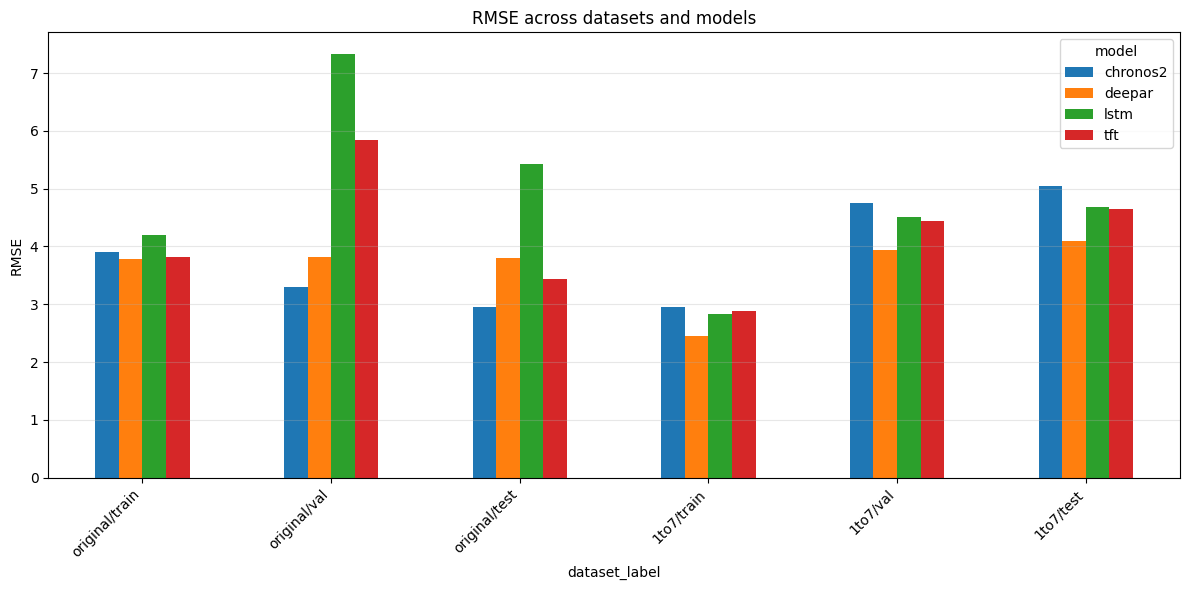

In [4]:
summary_df = pd.concat([train_df, chronos_df], ignore_index=True)
summary_df["dataset_label"] = summary_df["dataset"].str.replace("data_", "") + "/" + summary_df["split"]
order = [
    "original/train",
    "original/val",
    "original/test",
    "1to7/train",
    "1to7/val",
    "1to7/test",
]

summary_pivot = summary_df.pivot_table(
    index="dataset_label", columns="model", values="rmse"
).reindex(order)
summary_pivot # type: ignore

ax = summary_pivot.plot(kind="bar", figsize=(12, 6))
ax.set_ylabel("RMSE")
ax.set_title("RMSE across datasets and models")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
